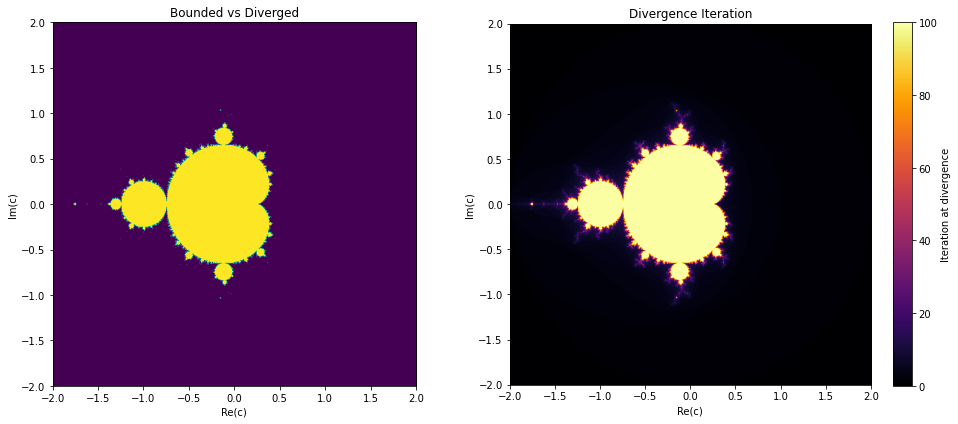

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from a3 import complex_iter

C, diverge_iter = complex_iter()
max_iter = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bounded = diverge_iter == max_iter
axes[0].imshow(bounded, extent=[-2, 2, -2, 2], origin='lower', cmap='viridis')
axes[0].set_title('Bounded vs Diverged')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')

img = axes[1].imshow(diverge_iter, extent=[-2, 2, -2, 2], origin='lower',
                     cmap='inferno', vmin=0, vmax=max_iter)
plt.colorbar(img, ax=axes[1], label='Iteration at divergence')
axes[1].set_title('Divergence Iteration')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')

plt.tight_layout()
plt.show()

In [45]:
def lorenz(t, W, sigma=10, r=28, b=8/3):
    """
    Compute the derivatives of the Lorenz system.

    Parameters:
        X, Y, Z : int or float
            Lorenz's values
        t : int or float
            time
        sigma : int or float
            Prandtl number
        r : int or float
            Rayleigh number
        b : int or float
            dimensionless length scale (default 8/3)

    Returns:
        dX/dt, dY/dt, dZ/dt : array
            time derivatives
    """
    X, Y, Z = W
    dX = -sigma * (X - Y)
    dY = r*X - Y - X*Z
    dZ = -b*Z + X*Y

    return dX, dY, dZ

In [33]:
from scipy.integrate import solve_ivp
W0 = 0, 1, 0
X0, Y0, Z0 = W0

t_span = (0, 60)
t_eval = np.linspace(0, 30, 3000)
sol = solve_ivp(lorenz, t_span, [X0, Y0, Z0], t_eval=t_eval, method='RK45')
X, Y, Z = sol.y
t = sol.t

# print(t)
# print(X, Y, Z)

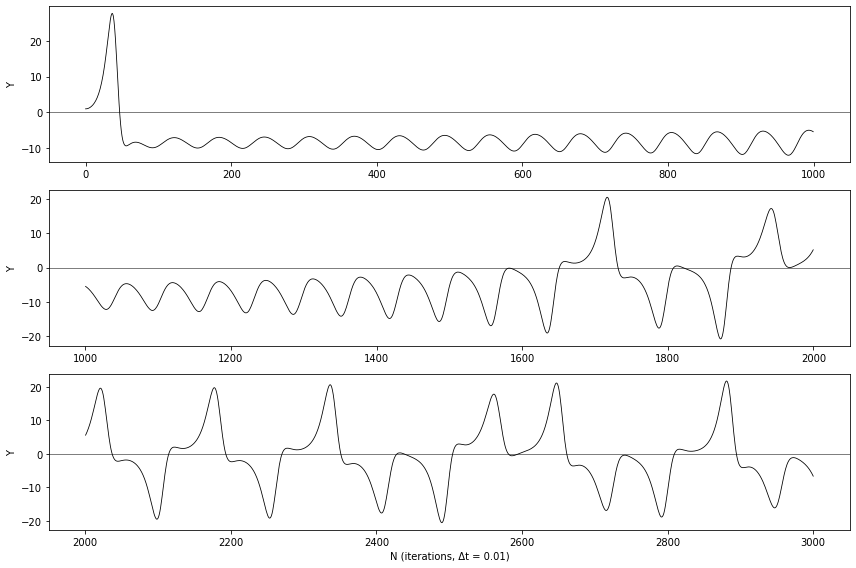

In [43]:
dt = 0.01
N = t / dt
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(N[:1000],        Y[:1000],        'k', linewidth=0.8)
axes[1].plot(N[1000:2000],    Y[1000:2000],    'k', linewidth=0.8)
axes[2].plot(N[2000:3000],    Y[2000:3000],    'k', linewidth=0.8)

for ax in axes:
    ax.set_ylabel('Y')
    ax.axhline(0, color='k', linewidth=0.5)

axes[2].set_xlabel('N (iterations, Δt = 0.01)')
plt.tight_layout()
plt.savefig('lorenz_fig1.png', dpi=150)
plt.show()

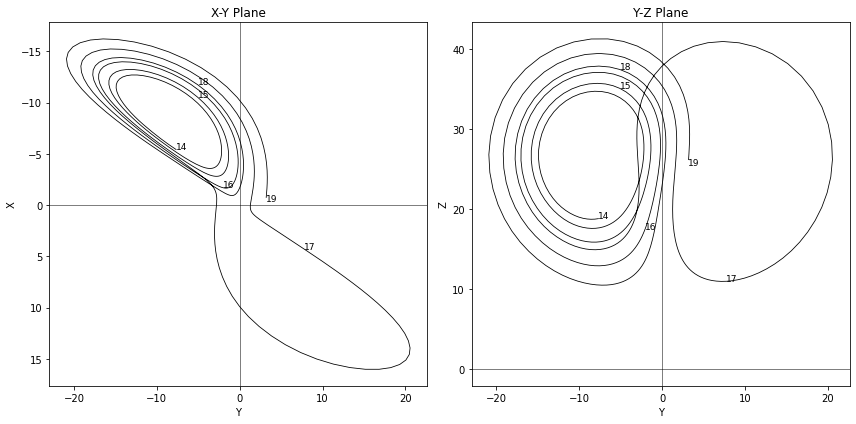

In [42]:
# Iterations 1400-1900
i1, i2 = 1400, 1900

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(Y[i1:i2], X[i1:i2], 'k', linewidth=0.8)
axes[0].set_xlabel('Y')
axes[0].set_ylabel('X')
axes[0].set_title('X-Y Plane')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(0, color='k', linewidth=0.5)
axes[0].invert_yaxis()

axes[1].plot(Y[i1:i2], Z[i1:i2], 'k', linewidth=0.8)
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')
axes[1].set_title('Y-Z Plane')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(0, color='k', linewidth=0.5)

# Mark every 100 iterations like Lorenz (14, 15, 16, ...)
for i, label in zip(range(i1, i2+1, 100), range(14, 20)):
    axes[0].annotate(str(label), (Y[i], X[i]), fontsize=9)
    axes[1].annotate(str(label), (Y[i], Z[i]), fontsize=9)

plt.tight_layout()
plt.savefig('lorenz_fig2.png', dpi=150)
plt.show()

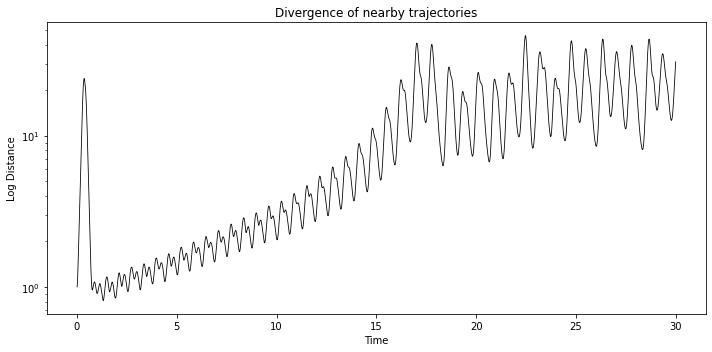

In [44]:
W0_ = np.array(W0) + np.array([0, 1. + 1.e-8, 0])

t_span = (0, 30)
t_eval = np.linspace(0, 30, 3000)

sol  = solve_ivp(lorenz, t_span, W0,  t_eval=t_eval, method='RK45')
solp = solve_ivp(lorenz, t_span, W0_, t_eval=t_eval, method='RK45')

X,  Y,  Z  = sol.y
Xp, Yp, Zp = solp.y
tp = sol.t

distance = np.sqrt((X - Xp)**2 + (Y - Yp)**2 + (Z - Zp)**2)


plt.figure(figsize=(10, 5))
plt.semilogy(tp, distance, 'k', linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Log Distance')
plt.title('Divergence of nearby trajectories')
plt.tight_layout()
plt.savefig('lorenz_divergence.png', dpi=150)
plt.show()